In [3]:
# ─── Post-processing: best‐per‐seed & summary stats ───────────────────────────
import os
import pandas as pd
import numpy as np

# Settings – adjust if needed
SEEDS = [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]         # 1..31
TOL   = 1e-6
BASE  = os.getcwd()
RESULTS_DIR = os.path.join(BASE, "Results-Direct-Optimization-WB")

# Collect best‐per‐seed
records = []
for seed in SEEDS:
    seed_dir = os.path.join(RESULTS_DIR, f"seed_{seed:02d}")
    print(seed_dir)
    # read in your saved CSVs
    df_c = pd.read_csv(os.path.join(seed_dir, "all_evals_constraints.csv"))
    df_o = pd.read_csv(os.path.join(seed_dir, "all_evals_objective.csv"))
    # merge on x1…x4
    xs = [f"x{i+1}" for i in range(4)]
    gs = [f"g{i+1}" for i in range(4)]
    df = pd.merge(df_o, df_c, on=xs)
    # filter feasible (all constraints ≤ TOL)
    feasible = df[ gs ].le(TOL).all(axis=1)
    df_feas = df.loc[feasible]
    if df_feas.empty:
        print(f"[WARN] No feasible solutions for seed {seed:02d}")
        continue
    # pick the minimum‐f row
    idx = df_feas["f"].idxmin()
    best = df_feas.loc[idx, ["f"]]
    best.name = f"seed_{seed:02d}"
    records.append(best)

# assemble DataFrame of best per seed
best_df = pd.DataFrame(records)

# compute summary statistics
stats_df = pd.DataFrame({
    "Min":    best_df.min(),
    "Max":    best_df.max(),
    "Median": best_df.median(),
    "Mean":   best_df.mean(),
    "Std":    best_df.std()
})

# print to console
print("\n=== Summary of best‐per‐seed results ===")
print(stats_df)

# write LaTeX table
out_tex = os.path.join(RESULTS_DIR, "results_statistics.tex")
latex = stats_df.to_latex(
    index=True,
    float_format="%.4f",
    caption="Summary statistics of best‐found solutions across seeds",
    label="tab:results_stats"
)
with open(out_tex, "w") as f:
    f.write(latex)
print(f"\nLaTeX table saved to: {out_tex}")


/Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/seed_01
/Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/seed_02
/Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/seed_03
/Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/seed_05
/Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/seed_06
/Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/seed_07
/Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/seed_08
/Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/seed_09
/Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/seed_10
/Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/seed_11
/Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/seed_12
/Users/ankushkapoor/D

In [4]:
print(best_df.median())

f    2.479077
dtype: float64


Using seed folder: seed_23


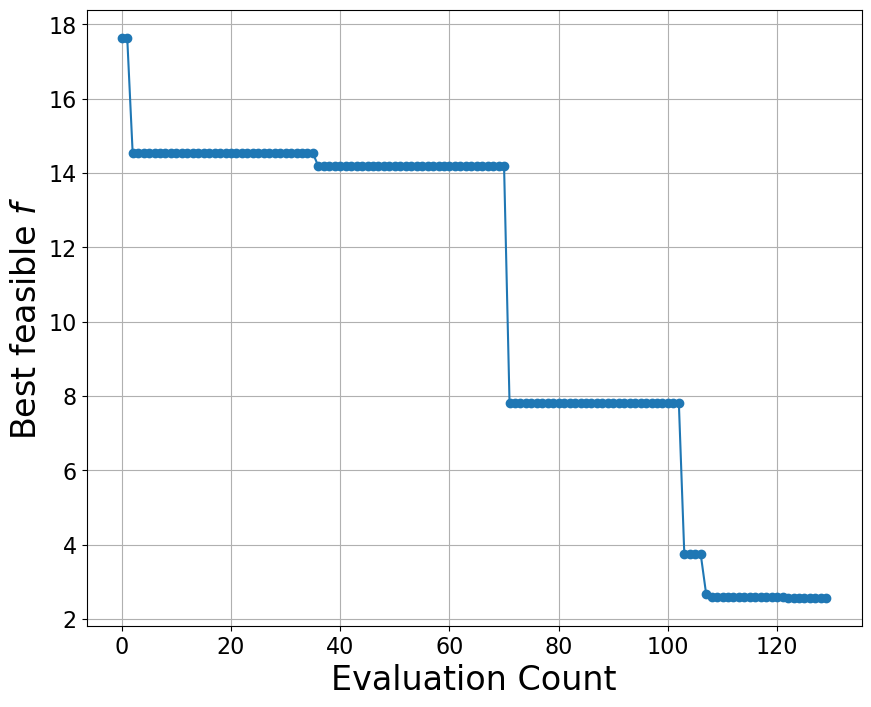

Figures saved to:
 • /Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/Results-Direct-Optimization-WB/figures/convergence_seed_23.png
 • /Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/Results-Direct-Optimization-WB/figures/convergence_seed_23.eps


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


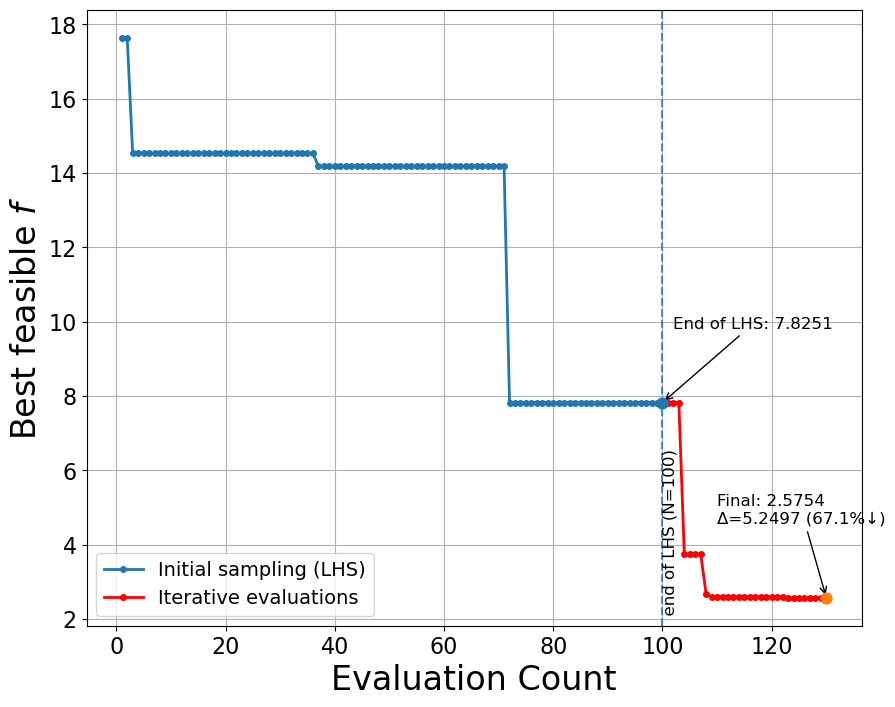

Figures saved to:
 • /Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/Results-Direct-Optimization-WB/figures/convergence_seed_23.png
 • /Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/Results-Direct-Optimization-WB/figures/convergence_seed_23.eps
Using seed folder for LHS trace: seed_23 (seed 23)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


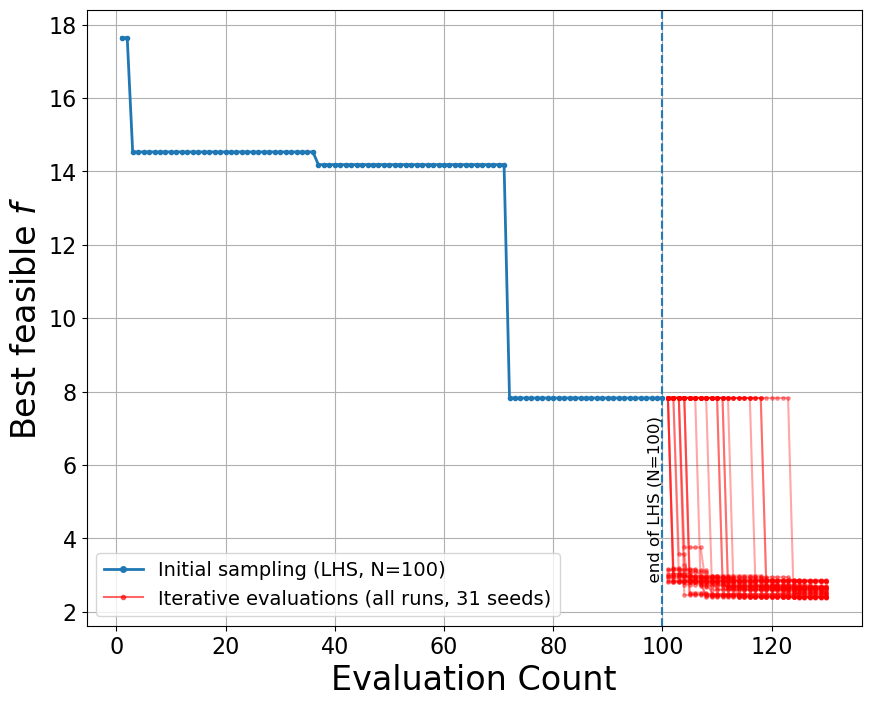

Figures saved to:
 • /Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/Results-Direct-Optimization-WB/figures/convergence_all_runs.png
 • /Users/ankushkapoor/Desktop/MILP_Paper/revision_1/Results-Direct-Optimization-WB/Results-Direct-Optimization-WB/figures/convergence_all_runs.eps


In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ─── Settings ────────────────────────────────────────────────────────────────
SEEDS = [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]         # 1..31
TOL         = 1e-6
BASE        = os.getcwd()
RESULTS_DIR = os.path.join(BASE, "Results-Direct-Optimization-WB")
FIG_DIR     = os.path.join(RESULTS_DIR, "Results-Direct-Optimization-WB", "figures")

# ensure figures folder exists
os.makedirs(FIG_DIR, exist_ok=True)

# ─── 1) Collect best‐per‐seed ────────────────────────────────────────────────
records = []
for seed in SEEDS:
    seed_dir = os.path.join(RESULTS_DIR, f"seed_{seed:02d}")
    df_c = pd.read_csv(os.path.join(seed_dir, "all_evals_constraints.csv"))
    df_o = pd.read_csv(os.path.join(seed_dir, "all_evals_objective.csv"))
    xs   = [f"x{i+1}" for i in range(4)]
    gs   = [f"g{i+1}" for i in range(4)]
    df   = pd.merge(df_o, df_c, on=xs)
    feasible = df[gs].le(TOL).all(axis=1)
    df_feas  = df.loc[feasible]
    if df_feas.empty:
        print(f"[WARN] No feasible solutions for seed {seed:02d}")
        continue
    idx      = df_feas["f"].idxmin()
    best     = df_feas.loc[idx, ["f"]].iloc[0]
    records.append((f"seed_{seed:02d}", best))

best_df = pd.DataFrame(records, columns=["seed","f"]).set_index("seed")

# ─── 2) Identify the “median” seed ───────────────────────────────────────────
sorted_seeds = best_df["f"].sort_values()
median_pos   = len(sorted_seeds) // 2
median_seed  = sorted_seeds.index[median_pos]
print(f"Using seed folder: {median_seed}")

# ─── 3) Load that seed’s full logs ───────────────────────────────────────────
seed_dir = os.path.join(RESULTS_DIR, median_seed)
dfF      = pd.read_csv(os.path.join(seed_dir, "all_evals_objective.csv"))
dfG      = pd.read_csv(os.path.join(seed_dir, "all_evals_constraints.csv"))

# ─── 4) Compute best‐so‐far feasible f ───────────────────────────────────────
G         = dfG[[f"g{i+1}" for i in range(4)]].values
feas_mask = (G <= TOL).all(axis=1)

f_vals    = dfF["f"].values
best_so_far = np.minimum.accumulate(
    np.where(feas_mask, f_vals, np.inf)
)

# ─── 5) Plot & save convergence ─────────────────────────────────────────────
#plt.figure()
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(best_so_far, marker="o", linestyle="-")
ax.set_xlabel("Evaluation Count", fontsize=24)
ax.set_ylabel("Best feasible $f$", fontsize=24)
#plt.title(f"Convergence plot (median seed = {med")
ax.tick_params(axis='both', labelsize=16)
ax.grid(True)
#ax.tight_layout()

# save to both PNG and EPS
png_path = os.path.join(FIG_DIR, f"convergence_{median_seed}.png")
eps_path = os.path.join(FIG_DIR, f"convergence_{median_seed}.eps")
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(eps_path, format='eps', dpi=300, bbox_inches="tight")
plt.show()

print(f"Figures saved to:\n • {png_path}\n • {eps_path}")


# ─── 5.b) Plot & save convergence (color initial vs iterative) ────────────────
N_INIT = 100  # initial LHS budget (first 100 evals)
fig, ax = plt.subplots(figsize=(10, 8))

n_total = len(best_so_far)
n_init = min(N_INIT, n_total)

# x starts at 1
x_init = np.arange(1, n_init + 1)
y_init = best_so_far[:n_init]

x_iter = np.arange(n_init + 1, n_total + 1)
y_iter = best_so_far[n_init:]

# plot initial (blue) and iterative (red)
ax.plot(x_init, y_init, marker="o", linestyle="-", linewidth=2, markersize=4,
        label="Initial sampling (LHS)")
if len(x_iter) > 0:
    ax.plot(x_iter, y_iter, marker="o", linestyle="-", linewidth=2, markersize=4,
            color="red", label="Iterative evaluations")

# split marker
ax.axvline(n_init, linestyle="--", linewidth=1.5, alpha=0.8)
ax.text(n_init, ax.get_ylim()[0], f"  end of LHS (N={n_init})", rotation=90,
        va="bottom", ha="left", fontsize=12)

# optional: annotate improvement from end of LHS to final
y_init_end = y_init[-1]
y_final = best_so_far[-1]
if np.isfinite(y_init_end) and np.isfinite(y_final) and y_init_end > 0:
    rel_impr = 100.0 * (y_init_end - y_final) / y_init_end
    abs_impr = (y_init_end - y_final)

    ax.scatter([n_init], [y_init_end], s=60, zorder=5)
    ax.scatter([n_total], [y_final], s=60, zorder=5)

    ax.annotate(f"End of LHS: {y_init_end:.4f}",
                xy=(n_init, y_init_end), xytext=(n_init + 2, y_init_end+2),
                arrowprops=dict(arrowstyle="->"), fontsize=12)
    ax.annotate(f"Final: {y_final:.4f}\nΔ={abs_impr:.4f} ({rel_impr:.1f}%↓)",
                xy=(n_total, y_final), xytext=(max(1, n_total - 20), y_final+2),
                arrowprops=dict(arrowstyle="->"), fontsize=12)

ax.set_xlabel("Evaluation Count", fontsize=24)
ax.set_ylabel("Best feasible $f$", fontsize=24)
ax.tick_params(axis='both', labelsize=16)
ax.grid(True)
ax.legend(fontsize=14)

# save to both PNG and EPS
png_path = os.path.join(FIG_DIR, f"convergence_{median_seed}.png")
eps_path = os.path.join(FIG_DIR, f"convergence_{median_seed}.eps")
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(eps_path, format='eps', dpi=300, bbox_inches="tight")
plt.show()

print(f"Figures saved to:\n • {png_path}\n • {eps_path}")


# ─── 5.c) Plot & save convergence: ALL runs overlaid after LHS ────────────────
N_INIT = 100  # initial LHS budget (first 100 evals)

# helper: compute best-so-far feasible for a given seed
def best_so_far_feasible_for_seed(seed, tol=TOL):
    seed_dir = os.path.join(RESULTS_DIR, f"seed_{seed:02d}")
    dfF = pd.read_csv(os.path.join(seed_dir, "all_evals_objective.csv"))
    dfG = pd.read_csv(os.path.join(seed_dir, "all_evals_constraints.csv"))

    G = dfG[[f"g{i+1}" for i in range(4)]].values
    feas_mask = (G <= tol).all(axis=1)

    f_vals = dfF["f"].values
    best_so_far = np.minimum.accumulate(np.where(feas_mask, f_vals, np.inf))
    return best_so_far

# compute median seed (as you already do)
sorted_seeds = best_df["f"].sort_values()
median_pos   = len(sorted_seeds) // 2
median_seed  = sorted_seeds.index[median_pos]          # like "seed_28"
median_seed_num = int(median_seed.split("_")[1])       # 28
print(f"Using seed folder for LHS trace: {median_seed} (seed {median_seed_num})")

# --- LHS trace from median seed (assumed shared / representative) ---
best_median = best_so_far_feasible_for_seed(median_seed_num, tol=TOL)
n_total_med = len(best_median)
n_init = min(N_INIT, n_total_med)

x_init = np.arange(1, n_init + 1)
y_init = best_median[:n_init]

# --- plot ---
fig, ax = plt.subplots(figsize=(10, 8))

# initial LHS (blue)
ax.plot(
    x_init, y_init,
    marker="o", linestyle="-", linewidth=2, markersize=3,
    label=f"Initial sampling (LHS, N={n_init})"
)

# split marker
ax.axvline(n_init, linestyle="--", linewidth=1.5, alpha=0.8)
ax.text(n_init, ax.get_ylim()[0], f"  end of LHS (N={n_init})", rotation=90,
        va="top", ha="right", fontsize=12)

# iterative stage (red) for ALL seeds
for seed in SEEDS:
    try:
        best_sf = best_so_far_feasible_for_seed(seed, tol=TOL)
    except FileNotFoundError:
        print(f"[WARN] Missing files for seed {seed:02d}, skipping.")
        continue

    n_total = len(best_sf)
    if n_total <= n_init:
        continue

    x_iter = np.arange(n_init + 1, n_total + 1)  # x starts at 1
    y_iter = best_sf[n_init:]

    # plot iterative segment only, overlaid
    ax.plot(
        x_iter, y_iter,
        marker="o", linestyle="-", linewidth=1.5, markersize=2.5,
        color="red", alpha=0.35
    )

# split marker at end of LHS
ax.axvline(n_init, linestyle="--", linewidth=1.5, alpha=0.8)

ax.set_xlabel("Evaluation Count", fontsize=24)
ax.set_ylabel("Best feasible $f$", fontsize=24)
ax.tick_params(axis='both', labelsize=16)
ax.grid(True)

# legend: show one red entry without labelling all 31 lines
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0],[0], color=ax.lines[0].get_color(), marker="o", linestyle="-", linewidth=2, markersize=4,
           label=f"Initial sampling (LHS, N={n_init})"),
    Line2D([0],[0], color="red", marker="o", linestyle="-", linewidth=1.5, markersize=3, alpha=0.6,
           label=f"Iterative evaluations (all runs, {len(SEEDS)} seeds)")
]
ax.legend(handles=legend_handles, fontsize=14)

# save to both PNG and EPS
png_path = os.path.join(FIG_DIR, "convergence_all_runs.png")
eps_path = os.path.join(FIG_DIR, "convergence_all_runs.eps")
fig.savefig(png_path, dpi=300, bbox_inches="tight")
fig.savefig(eps_path, format="eps", dpi=300, bbox_inches="tight")
plt.show()

print(f"Figures saved to:\n • {png_path}\n • {eps_path}")



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pysr import PySRRegressor
from sympy import simplify

# --- 2.1  load data ------------------------------------------------------------
XG = pd.read_csv("welded_beam_constraints.csv")
XF = pd.read_csv("welded_beam_objective.csv")
X  = XF[[f"x{i+1}" for i in range(4)]].values
y_f = XF["f"].values
y_g = [XG[f"g{i+1}"].values for i in range(4)]

# --- 2.2  helper to fit one PySR model ---------------------------------------
def train_pysr(y, name):
    model = PySRRegressor(
        maxsize=20,
        niterations=60,
        binary_operators=["+", "-", "*", "/"],
        unary_operators=["sin", "cos", "exp", "log", "inv(x)=1/x"],
        extra_sympy_mappings={"inv": lambda z: 1/z},
        elementwise_loss="loss(p,t) = (p - t)^2",
        progress=False,
    )
    model.fit(X, y)
    best_idx = model.equations_.sort_values("loss").index[0]
    expr = simplify(model.sympy(best_idx))
    print(f"Best expression for {name}: {expr}")
    return model, expr

# --- 2.3  train regressors ----------------------------------------------------
model_f, expr_f = train_pysr(y_f, "f")
models_g = []
exprs_g = []
for i in range(4):
    m, e = train_pysr(y_g[i], f"g{i+1}")
    models_g.append(m)
    exprs_g.append(e)

# --- 2.4  predict on training X ----------------------------------------------
pred_f = model_f.predict(X)
pred_g = [m.predict(X) for m in models_g]

# --- 2.5  plot true vs. predicted --------------------------------------------
# Objective f
plt.figure()
plt.scatter(y_f, pred_f)
plt.plot([y_f.min(), y_f.max()], [y_f.min(), y_f.max()])
plt.xlabel("True f")
plt.ylabel("Predicted f")
plt.title("f: True vs. Predicted")
plt.grid(True)

# Constraints g1…g4
for i in range(4):
    true = y_g[i]
    pred = pred_g[i]
    plt.figure()
    plt.scatter(true, pred)
    mn, mx = true.min(), true.max()
    plt.plot([mn, mx], [mn, mx])
    plt.xlabel(f"True g{i+1}")
    plt.ylabel(f"Predicted g{i+1}")
    plt.title(f"g{i+1}: True vs. Predicted")
    plt.grid(True)

plt.show()
